<a href="https://colab.research.google.com/github/annhater/M1_STAGE/blob/main/2_notebooks/03_plot_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CLUSTERING FOR FREQUENCIES


In [ ]:
!pip install graphviz
!pip install pydotplus

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [279]:
# Load libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split # Import train_test_split function
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation


In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

#SETUP
rootdir = '/content/drive/MyDrive/M1_STAGE/Data/interactions/'
os.chdir(rootdir)

#FUNCTIONS
# a. Open interactions file
def find_hbonds(df):
    hydrogen_bonds = [col for col in df.columns if 'hb' in col]
    return hydrogen_bonds

#MAIN

# interaction_files = ['res_V1.csv', 'res_V11.csv', 'res_V12.csv', 'res_V7.csv', 'res_V8.csv', 'res_V21.csv']
# simulation_names = ['V1', 'V11', 'V12', 'V7', 'V8', 'V21']

interaction_files = ['res_V12.csv','res_V7.csv']
simulation_names = ['V12', 'V7']

# This dictionary will store all calculated frequencies, keyed by phase name
all_phase_frequencies = {}

# selected_frames_dico = {'V1' : range(412,587+1),
#                         'V12': range(0, 175+1),
#                         'V7': range(75,250+1),
#                         'V8' : range(62,237+1),
#                         'V21' : range(62,237+1),
#                         'V11' : range(698,873+1),
#                         }

selected_frames_dico = {'V12': range(0, 175+1),
                        'V7': range(75,250+1)
                        }

phase_limit_dico = {
    'V7': 198,
    'V8': 180,
    'V21': 155,
    'V12': 35,
    'V11': 1000,
    'V1': 517,
}

# Define the desired order of columns in the final frequency table

# phases_list_ordered = ['V1_ph1','V1_ph2','V12_ph1','V12_ph2',
#                        'V7_ph1','V7_ph2','V8_ph1','V8_ph2',
#                        'V21_ph1','V21_ph2', 'V11_ph1', 'V11_ph2']

phases_list_ordered = ['V12_ph1','V12_ph2','V7_ph1','V7_ph2']

for i, sim_file in enumerate(interaction_files):
    current_simulation_name = simulation_names[i]

    # 1. Load the full DataFrame
    df_full = pd.read_csv(sim_file)

    # 2. Get the transition state slice based on selected_frames_dico
    df_trans_state = pd.DataFrame() # Initialize to avoid UnboundLocalError
    if current_simulation_name in selected_frames_dico:
        frame_range_obj = selected_frames_dico[current_simulation_name]
        # Use df_full.index.isin() for robust selection of indices within the range
        valid_indices = [idx for idx in df_full.index if idx in frame_range_obj]
        df_trans_state = df_full.loc[valid_indices]

    # 3. Determine phase limit for the current simulation
    phase_limit = phase_limit_dico.get(current_simulation_name)

    # 4. Separate into phase 1 and phase 2 DataFrames based on the phase_limit
    # Ensure we are slicing based on the *actual indices* present in df_trans_state
    # Get the max index for phase 1 and min index for phase 2 that respect phase_limit
    ph1_indices = df_trans_state.index[df_trans_state.index <= phase_limit]
    ph2_indices = df_trans_state.index[df_trans_state.index > phase_limit]

    df_ph1 = df_trans_state.loc[ph1_indices] if not ph1_indices.empty else pd.DataFrame(columns=df_trans_state.columns)
    df_ph2 = df_trans_state.loc[ph2_indices] if not ph2_indices.empty else pd.DataFrame(columns=df_trans_state.columns)

    n_frames_ph1 = len(df_ph1)
    n_frames_ph2 = len(df_ph2)

    # 5. Find all hydrogen bonds in the entire transition state DataFrame
    # This ensures all phases calculate frequencies for the same set of bonds
    all_hbonds_in_trans_state = find_hbonds(df_trans_state)

    # # 6. Calculate frequencies for Phase 1
    ph1_name = f"{current_simulation_name}_ph1"
    current_ph1_frequencies = {}
    for hbond_col in all_hbonds_in_trans_state:
        if hbond_col in df_ph1.columns and n_frames_ph1 > 0:
            frequency = (df_ph1[hbond_col] > 0).sum() / n_frames_ph1 * 100
        current_ph1_frequencies[hbond_col] = frequency
    all_phase_frequencies[ph1_name] = current_ph1_frequencies

    # 7. Calculate frequencies for Phase 2
    ph2_name = f"{current_simulation_name}_ph2"
    current_ph2_frequencies = {}
    for hbond_col in all_hbonds_in_trans_state:
        if hbond_col in df_ph2.columns and n_frames_ph2 > 0:
            frequency = (df_ph2[hbond_col] > 0).sum() / n_frames_ph2 * 100
        current_ph2_frequencies[hbond_col] = frequency
    all_phase_frequencies[ph2_name] = current_ph2_frequencies

    # 6b. Alternatively calculate frequencies for all bonds
        # 6. Calculate frequencies for Phase 1
    # ph1_name = f"{current_simulation_name}_ph1"
    # current_ph1_frequencies = {}
    # for bonds in df_trans_state.columns:
    #     frequency = (df_ph1[bonds] > 0).sum() / n_frames_ph1 * 100
    #     current_ph1_frequencies[bonds] = frequency
    # all_phase_frequencies[ph1_name] = current_ph1_frequencies

    # # 7. Calculate frequencies for Phase 2
    # ph2_name = f"{current_simulation_name}_ph2"
    # current_ph2_frequencies = {}
    # for bonds in df_trans_state.columns:
    #     frequency = (df_ph2[bonds] > 0).sum() / n_frames_ph2 * 100
    #     current_ph2_frequencies[bonds] = frequency
    # all_phase_frequencies[ph2_name] = current_ph2_frequencies

# 8. Convert the dictionary of dictionaries to a DataFrame
# The keys of all_phase_frequencies will become column names, and inner keys will become index
freq_table = pd.DataFrame(all_phase_frequencies)

# 9. Ensure the columns are in the desired order
# Only include columns that were actually generated
existing_ordered_columns = [col for col in phases_list_ordered if col in freq_table.columns]
freq_table = freq_table[existing_ordered_columns]

# 10. Filter out rows (hbonds) where all frequencies across phases are zero
freq_table = freq_table[freq_table.sum(axis=1) > 0]
filtered_freq_table = freq_table[(freq_table > 80).any(axis=1)] # Corrected to filter rows based on the condition

# Save to CSV
#output_path = '/content/drive/MyDrive/M1_STAGE/Documents/M1_STAGE/Manips/Tables/interactions_V7_V12.csv'

# Ensure the directory exists

#freq_table.to_csv(output_path, index=True, header=True, decimal=".", float_format="%.5f")


In [280]:
# 1. Transpose: Rows = Samples (Phases), Columns = Features (Bonds)
X = filtered_freq_table.T

# 2. Define the Target: The index names of the transposed table (the phases)
y = X.index

# 3. Use the Bond names as your feature names
feature_cols = X.columns

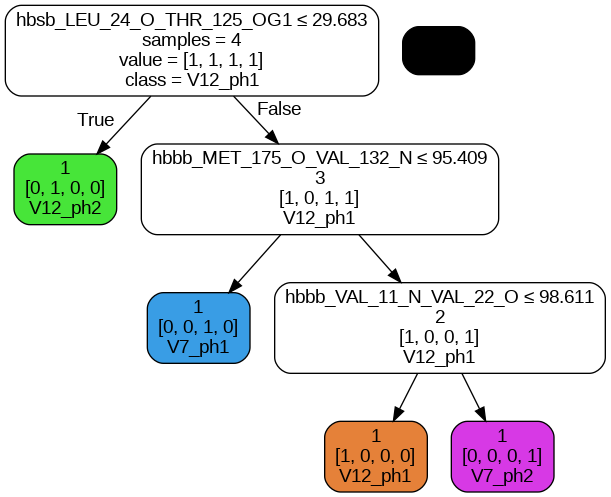

In [281]:
from sklearn.tree import export_graphviz
from io import StringIO
from IPython.display import Image
import pydotplus

# Fit the Decision Tree Classifier before exporting it
clf.fit(X, y)

dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True,
                rounded=True,
                special_characters=True,
                feature_names=feature_cols,
                class_names=y.unique().tolist(),
                impurity=False,
                label='root',
                proportion=False)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())
#save image


In [285]:
graph.write_png('decision_tree_V12_V7.png')

True

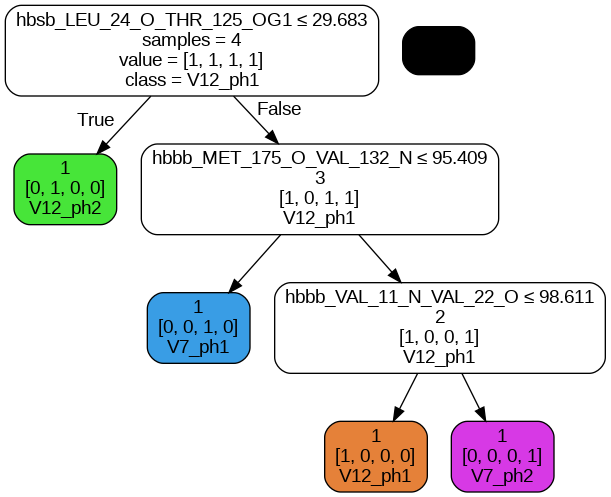

In [286]:
Image(graph.create_png())


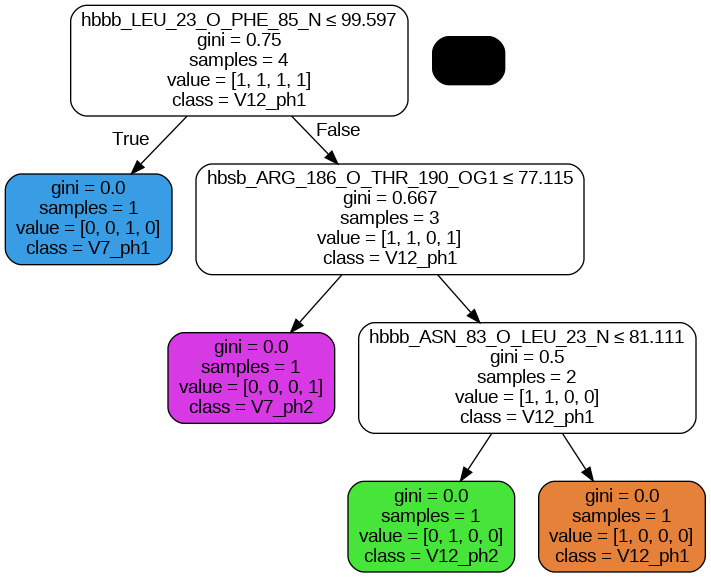

In [ ]:
# Fit the model on the transposed data
clf = DecisionTreeClassifier(max_depth=4)
clf.fit(X, y)

dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,
                feature_names=feature_cols,
                class_names=y.unique().tolist())

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

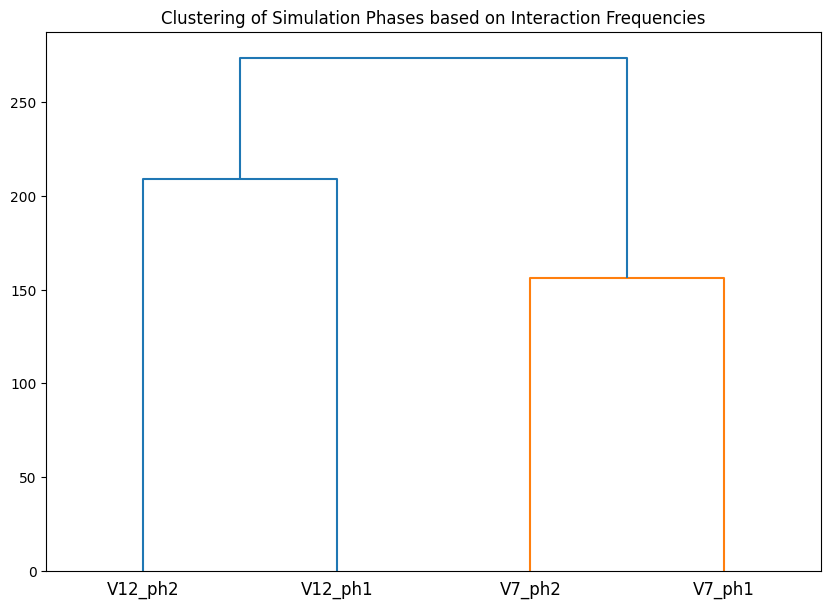

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt


linked = linkage(X, 'complete')

plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='top',
           labels=y.tolist(), # Phase names
           distance_sort='descending',
           show_leaf_counts=True)
plt.title("Clustering of Simulation Phases based on Interaction Frequencies")
plt.show()

# CLUSTERING BASED ON RMSD

In [ ]:
#SETUP
rootdir = '/content/drive/MyDrive/M1_STAGE/Manips/Tables'
os.chdir(rootdir)

df = pd.read_csv("trans_st_RMSD.csv")

df_sele = df[["V12_RMSD","V7_RMSD"]]

y = df_sele.columns.tolist()

In [ ]:
X = df_sele.T

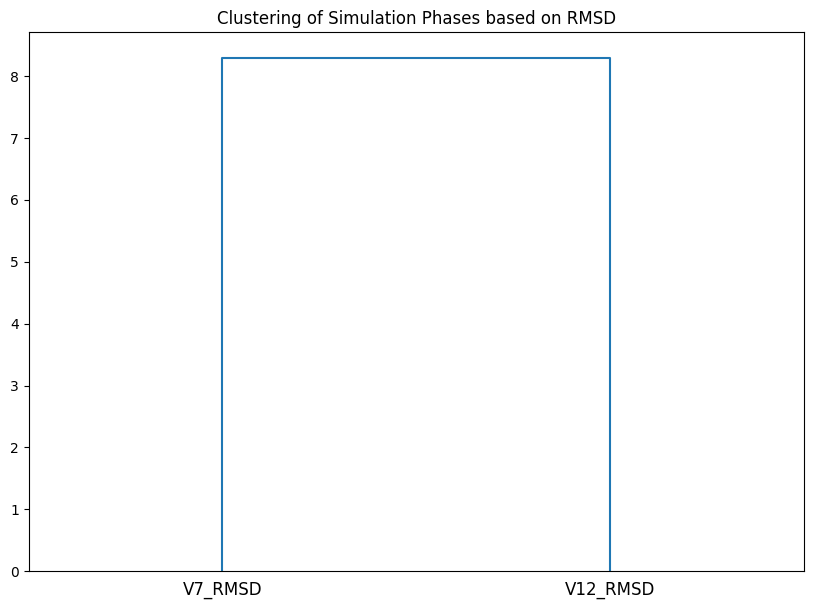

In [ ]:
import numpy as np

# It's good practice to ensure the input to linkage is a numpy array
# X is currently a pandas DataFrame (2 rows, 176 columns)
# Convert it to a numpy array
X_np = X.to_numpy()

linked = linkage(X_np, "ward")
plt.figure(figsize=(10, 7))
dendrogram(linked,
           orientation='top',
           labels=y, # Phase names
           distance_sort='descending',
           show_leaf_counts=True)
plt.title("Clustering of Simulation Phases based on RMSD")
plt.show()

## CLUSTERING FOR INDIVIDUAL FRAMES BASED ON RMSD

In [ ]:
# 1. Prepare data for frame-wise clustering
# Create a new structure where each row is an individual frame from either V7 or V12
frames_data = []
frames_labels = []

for i in range(len(df)):
    current_df_row = df.loc[i]

    # Process V7 data
    v7_frame = current_df_row['V7_frames']
    v7_rmsd = current_df_row['V7_RMSD']
    v7_phase = 'ph1' if v7_frame <= phase_limit_dico['V7'] else 'ph2'
    frames_data.append({'RMSD_Value': v7_rmsd})
    frames_labels.append(f"V7_F{int(v7_frame)}_{v7_phase}")

    # Process V12 data
    v12_frame = current_df_row['V12_frames']
    v12_rmsd = current_df_row['V12_RMSD']
    v12_phase = 'ph1' if v12_frame <= phase_limit_dico['V12'] else 'ph2'
    frames_data.append({'RMSD_Value': v12_rmsd})
    frames_labels.append(f"V12_F{int(v12_frame)}_{v12_phase}")

X_frames = pd.DataFrame(frames_data)
y_frames = frames_labels

print(f"Shape of X_frames: {X_frames.shape}")
print(f"Number of y_frames labels: {len(y_frames)}")
print(f"Example y_frames label (V7): {y_frames[0]}") # Show an example V7 label
print(f"Example y_frames label (V12): {y_frames[1]}") # Show an example V12 label

Shape of X_frames: (352, 1)
Number of y_frames labels: 352
Example y_frames label (V7): V7_F75_ph1
Example y_frames label (V12): V12_F0_ph1


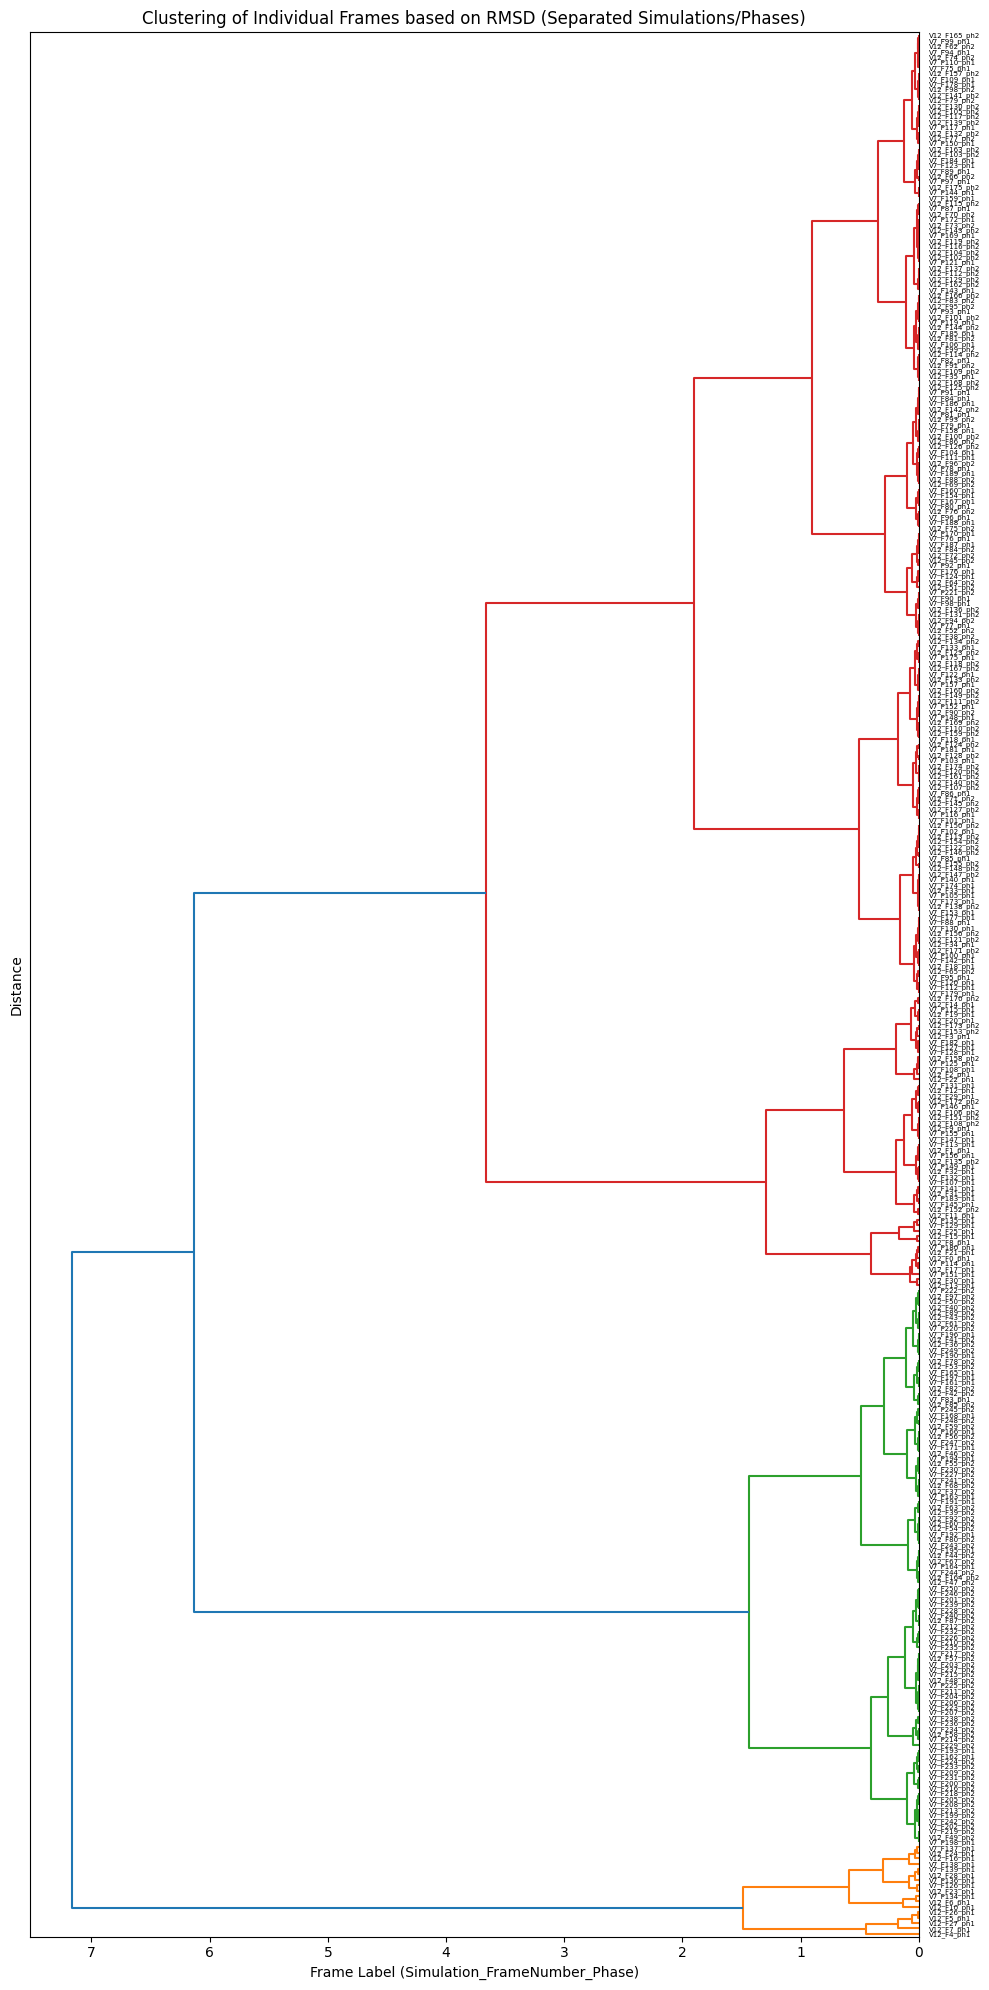

In [265]:
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Convert X_frames to a NumPy array for linkage.
# Reshape to ensure it's a 2D array (n_samples, n_features) even if n_features is 1.
X_frames_np = X_frames['RMSD_Value'].to_numpy().reshape(-1, 1)

# Perform hierarchical clustering on frames
linked_frames = linkage(X_frames_np, "ward")

fig = plt.figure(figsize=(10, 20)) # Increase figure size for more labels
dendrogram(linked_frames,
           orientation='left',
           labels=y_frames,
           show_leaf_counts=True, # Too many leaves, might clutter
           leaf_rotation=0,  # Rotate labels for better readability
           leaf_font_size=5) # Reduce font size for many labels
plt.title("Clustering of Individual Frames based on RMSD (Separated Simulations/Phases)")
plt.xlabel("Frame Label (Simulation_FrameNumber_Phase)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [263]:
fig.savefig('RMSD_frames.png', dpi=300, bbox_inches='tight')

In [270]:
# Instead of PCA, directly plot RMSD values with coloring
X = X_frames['RMSD_Value'] # This is a Series now
y = y_frames # This is a list of labels

# Create a DataFrame for Plotly Express
plot_df = pd.DataFrame()
plot_df['RMSD_Value'] = X

# Extract simulation and phase for coloring
plot_df['simulation'] = [label.split('_')[0] for label in y]
plot_df['phase'] = [label.split('_')[2] for label in y]
plot_df['simulation_phase'] = plot_df['simulation'] + '_' + plot_df['phase']

# Add a dummy y-axis for visualization
plot_df['dummy_y_axis'] = 0

fig = px.scatter(plot_df, x='RMSD_Value', y='dummy_y_axis',
                 color='simulation_phase', # Color by combined simulation and phase
                 title='RMSD Values for Individual Frames (Color-Coded by Simulation and Phase)',
                 labels={'dummy_y_axis': ''}) # Hide y-axis label
fig.update_traces(marker=dict(size=8, opacity=0.7),
                  jitter=0.3) # Add jitter to better visualize overlapping points
fig.update_layout(showlegend=True, yaxis_visible=False, yaxis_showticklabels=False) # Hide y-axis
fig.show()

ValueError: Invalid property specified for object of type plotly.graph_objs.Scatter: 'jitter'

Did you mean "line"?

    Valid properties:
        alignmentgroup
            Set several traces linked to the same position axis or
            matching axes to the same alignmentgroup. This controls
            whether bars compute their positional range dependently
            or independently.
        cliponaxis
            Determines whether or not markers and text nodes are
            clipped about the subplot axes. To show markers and
            text nodes above axis lines and tick labels, make sure
            to set `xaxis.layer` and `yaxis.layer` to *below
            traces*.
        connectgaps
            Determines whether or not gaps (i.e. {nan} or missing
            values) in the provided data arrays are connected.
        customdata
            Assigns extra data each datum. This may be useful when
            listening to hover, click and selection events. Note
        

# PCA FOR FRAMES


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [ ]:
#SETUP
rootdir = '/content/drive/MyDrive/M1_STAGE/Manips/Tables'
os.chdir(rootdir)

In [ ]:
#Read csv
csv_to_read = ['V7_ph1_interactions.csv', 'V7_ph2_interactions.csv',
               'V12_ph1_interactions.csv', 'V12_ph2_interactions.csv']
df_full = pd.DataFrame()
for i, f in enumerate(csv_to_read):
    elements = f.split('_')
    sim_phase = f'{elements[0]}_{elements[1]}'
    df_temp = pd.read_csv(f)
    hbonds = find_hbonds(df_temp)
    df_temp = df_temp[hbonds]
    df_temp["label"] = sim_phase
    #print(sim_phase)
    #print(df_temp.head())
    df_full = pd.concat([df_full, df_temp])

In [ ]:
for i, row in df_full.iterrows():
    # Exclude the 'label' column from the sum calculation for each row
    # Use errors='ignore' in case 'label' column is somehow already dropped or not present
    if row.drop('label', errors='ignore').sum() == 0:
        df_full = df_full.drop(i)

# Iterate through a copy of columns to avoid issues when dropping columns
for col_name in df_full.columns.copy():
    if col_name == 'label':
        continue # Skip the 'label' column as it's not numerical

    # Check if the column is numerical before attempting to sum
    if pd.api.types.is_numeric_dtype(df_full[col_name]):
        if df_full[col_name].sum() == 0:
            df_full = df_full.drop(columns=[col_name])

In [275]:
X

,hbbb_ASN_40_O_TYR_42_N,hbbb_GLN_18_N_GLY_17_N,hbsb_MET_76_O_THR_77_OG1,hbbb_ILE_82_N_THR_80_O,hbsb_GLY_138_O_TYR_158_OH,hbsb_LYS_156_NZ_THR_176_O,hbsb_ARG_72_NH1_ASN_61_O,hbsb_GLY_86_N_SER_31_OG,hbbb_ALA_172_O_ASN_160_N,hbss_GLU_157_OE1_SER_142_OG,...,hbsb_ILE_153_O_THR_155_OG1,hbbb_GLU_58_N_SER_43_O,hbsb_ARG_107_NH2_GLY_27_O,hbss_ARG_171_NE_ASN_160_ND2,hbbb_GLY_52_O_ILE_54_N,hbsb_ASN_83_ND2_VAL_33_N,hbbb_GLN_117_O_ILE_114_N,hbss_GLN_2_OE1_SER_195_OG,hbsb_ALA_133_N_ASN_182_OD1,RMSD_Value
0,1,0,0,0,1,0,0,1,1,0,...,0,1,0,0,0,0,1,0,1,1.413
1,1,0,0,0,1,0,0,1,0,0,...,0,1,0,0,0,0,1,0,1,1.990
2,1,0,0,0,1,0,0,1,0,0,...,0,1,0,0,0,0,1,0,1,1.227
3,0,0,0,0,1,0,0,1,0,0,...,0,1,0,0,0,0,1,0,1,1.655
4,0,0,0,0,1,0,0,1,0,0,...,0,1,0,0,0,0,1,0,1,1.244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,1,0,1,1.144
136,0,1,0,1,0,0,0,1,0,0,...,0,1,0,0,0,0,1,0,1,1.329
137,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,1,0,1,1.042
138,0,0,0,0,0,0,0,1,1,0,...,0,1,0,0,0,0,1,0,1,1.450


In [272]:
# Create a copy of df_full to work with and avoid modifying the original
df_pca = df_full.copy()

# Add RMSD values as a new feature.
# Assuming df_full and X_frames are aligned row-wise (same number of rows and same order).
df_pca['RMSD_Value'] = X_frames['RMSD_Value']

# Separate features (X) and target (y)
X = df_pca.drop(columns='label', axis=1)
y = df_pca['label']

# Standardize the features before PCA, as they might be on different scales
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA
pca = PCA(n_components=2) # Keep 2 principal components for visualization
components = pca.fit_transform(X_scaled)

# Create a DataFrame for Plotly Express for easier plotting and coloring
pca_result_df = pd.DataFrame(data = components, columns = ['principal_component_1', 'principal_component_2'])
pca_result_df['label'] = y.reset_index(drop=True) # Ensure labels align correctly with components

# Plot the PCA results
fig = px.scatter(pca_result_df, x='principal_component_1', y='principal_component_2', color='label',
                 title='PCA of Interactions and RMSD')
fig.update_traces(marker=dict(size=8, opacity=0.7))
fig.show()

In [ ]:
X = df_full.drop('label', axis=1)
y = df_full['label']